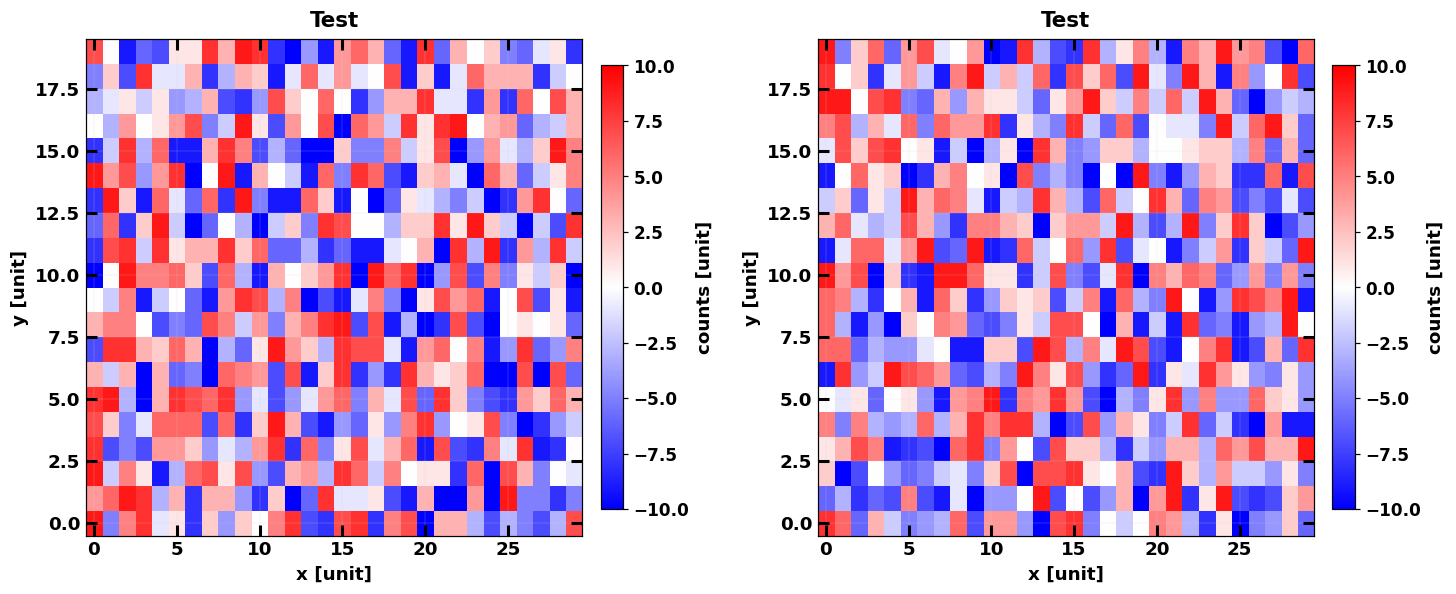

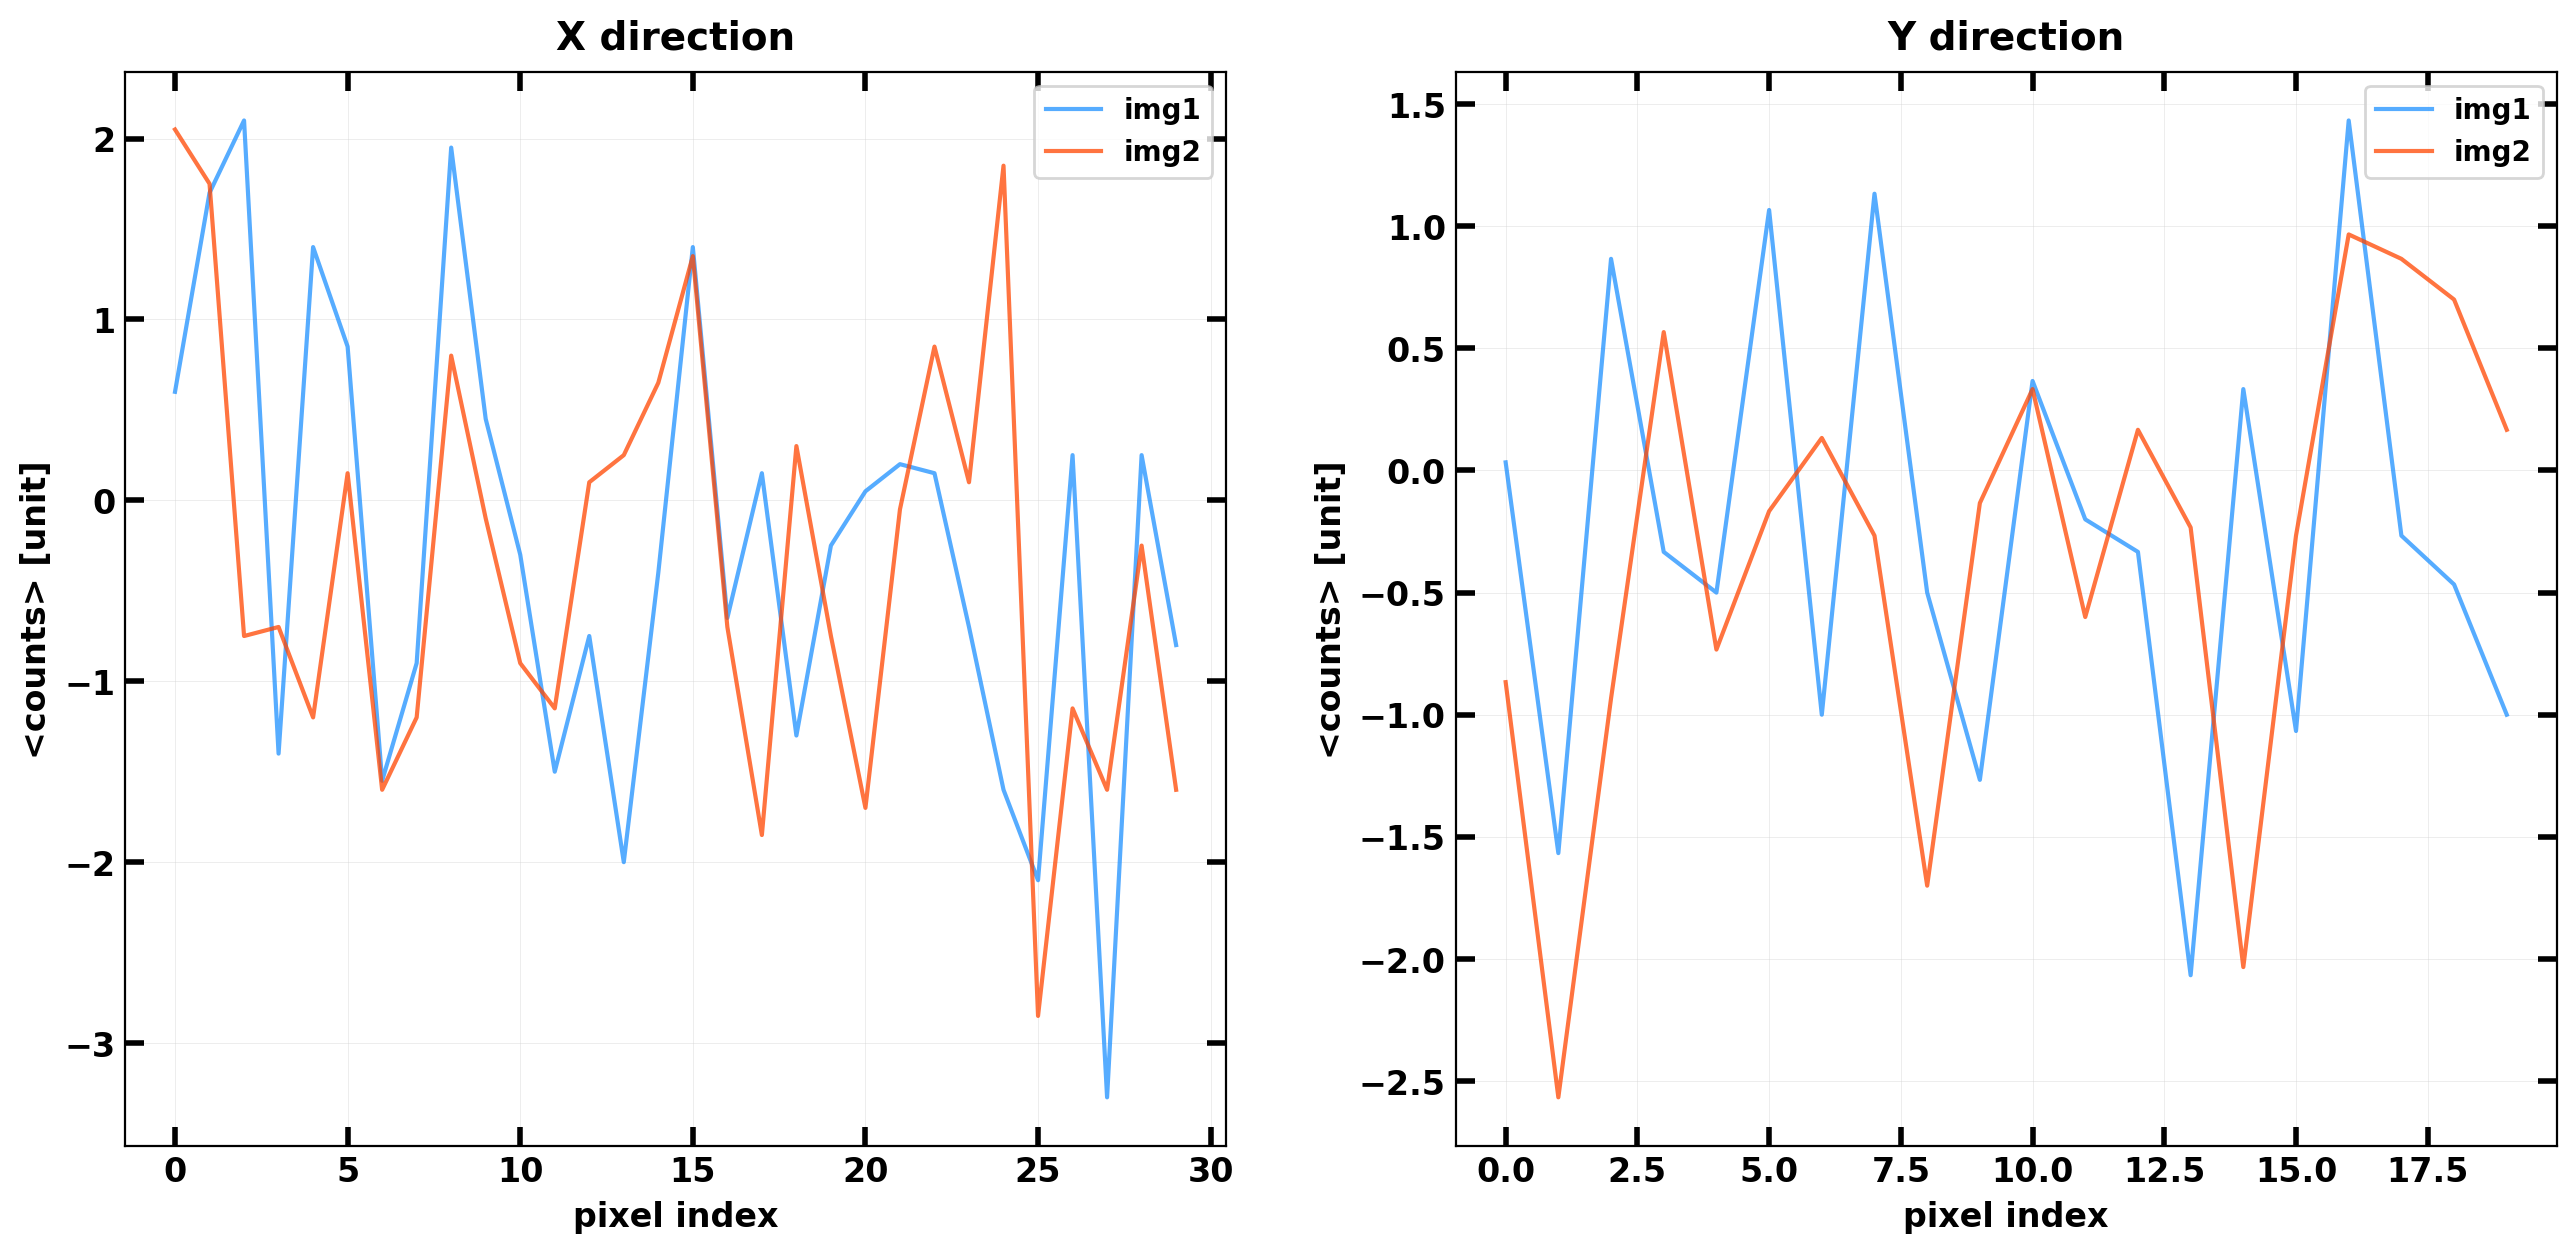

In [1]:
import numpy as np
from darksun.show import map4plot, plot, map4image, image_plot

n, m = 20, 30
img1 = np.random.randint(-10, 10, (n, m))
img2 = np.random.randint(-10, 10, (n, m))

ASPECT = m / n
kw = {
    'cmap': 'bwr',
    'aspect': ASPECT,
    'vmin': -10,
    'vmax': 10,
}
dmap1 = map4image(
    img1,
    title='Test',
    xlabel='x [unit]',
    ylabel='y [unit]',
    cbarlabel='counts [unit]',
    cbarloc='right',
    img_kwargs=kw,
)
dmap2 = map4image(
    img2,
    title='Test',
    xlabel='x [unit]',
    ylabel='y [unit]',
    cbarlabel='counts [unit]',
    cbarloc='right',
    img_kwargs=kw,
)
image_plot(dmaps=(dmap1, dmap2), ncols=2)




collapsed_x1, collapsed_x2 = map(
    lambda x: np.sum(x, axis=0) / n,
    (img1, img2),
)
collapsed_y1, collapsed_y2 = map(
    lambda x: np.sum(x, axis=1) / m,
    (img1, img2),
)
dmapx = map4plot(
    arrs=(
        collapsed_x1, collapsed_x2,
    ),
    title='X direction',
    ylabel='<counts> [unit]',
    xlabel='pixel index',
    labels=('img1', 'img2'),
    color=('DodgerBlue', 'OrangeRed')
)
dmapy = map4plot(
    arrs=(
        collapsed_y1, collapsed_y2,
    ),
    title='Y direction',
    ylabel='<counts> [unit]',
    xlabel='pixel index',
    labels=('img1', 'img2'),
    color=('DodgerBlue', 'OrangeRed')
)
plot(dmaps=(dmapx, dmapy), ncols=2)

In [ ]:
import numpy as np
from scipy.ndimage import shift as ndshift

from fract_shift import fshift


def scipy_fshift(arr, shifty, shiftx):
    arr_ = ndshift(
        arr, (shifty, shiftx), output='float', order=1, mode='grid-constant', cval=0.0, prefilter=True,
    )
    return arr_

TOL = 1e-5

a = np.ones((10, 10))
b = (
    (fshift(a, 0, -1), scipy_fshift(a, 0, -1)),
    (fshift(a, 1.6, 0), scipy_fshift(a, 1.6, 0)),
    (fshift(a, -1.6, 0), scipy_fshift(a, -1.6, 0)),
    (fshift(a, 0, 1.6), scipy_fshift(a, 0, 1.6)),
    (fshift(a, 0, -1.6), scipy_fshift(a, 0, -1.6)),
    (fshift(a, 1.3, -1.2), scipy_fshift(a, 1.3, -1.2)),

    (fshift(a, 0, -1), scipy_fshift(a, 0, -1)),
    (fshift(a, 3.1, 0), scipy_fshift(a, 3.1, 0)),
    (fshift(a, -7.8, 0), scipy_fshift(a, -7.8, 0)),
    (fshift(a, 0, 5.2), scipy_fshift(a, 0, 5.2)),
    (fshift(a, 0, -2.8), scipy_fshift(a, 0, -2.8)),
    (fshift(a, 9.3, -4.2), scipy_fshift(a, 9.3, -4.2)),
)

for idx, (fs, scipyfs) in enumerate(b):
    assert np.all(np.abs(fs - scipyfs) < TOL), f"Failed at idx {idx}.\nFS:\n{fs}\n\nSCIPYFS:\n{scipyfs}"



from timeit import timeit
REP = 20

a = np.ones((650, 1040))
sy, sx = 100, 100

t1 = timeit('fshift(a, sy, sx)', globals=globals(), number=REP)        # faster on single cell !!
t2 = timeit('scipy_fshift(a, sy, sx)', globals=globals(), number=REP)  # slower on single cell !!

t1 / REP, t2 / REP

(0.0034183063498858246, 0.014397418200132961)

67.4062673086537 40.91037670575773 (np.float64(-168.9843317283657), np.float64(-163.8584931769691)) (650, 1040)


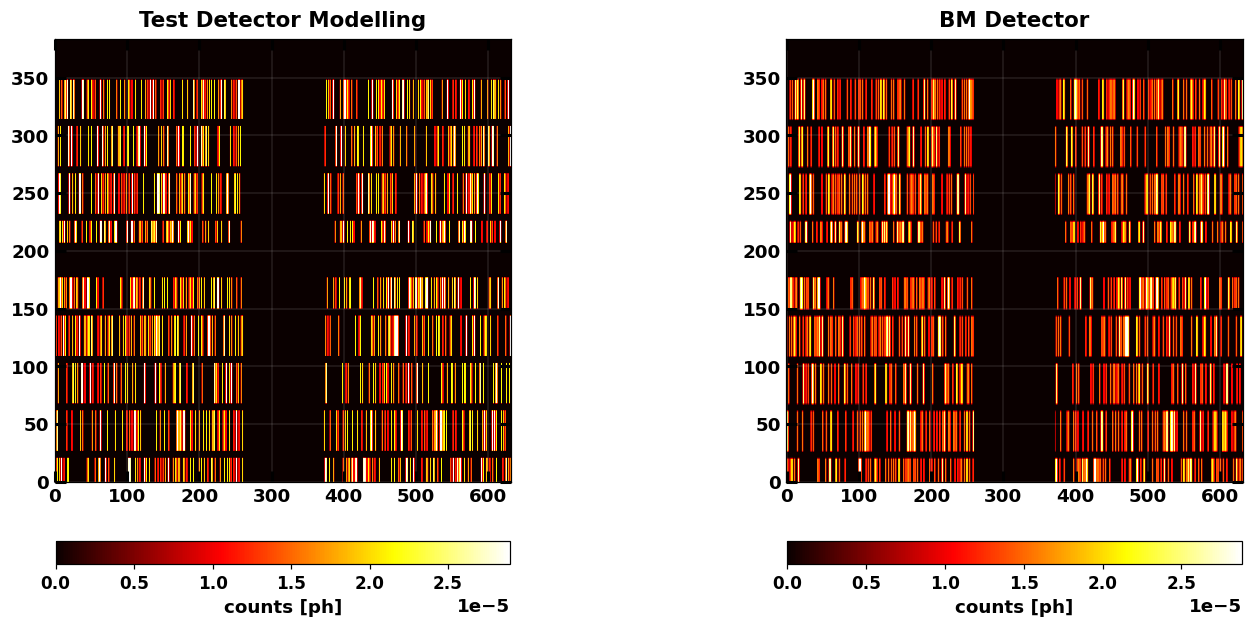

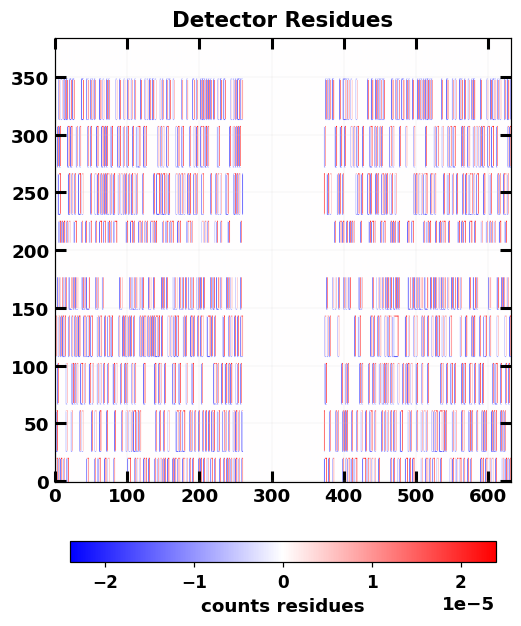

In [1]:
import numpy as np

from bloodmoon.mask import codedmask
from darksun.show import map4image, image_plot

from bloodmoon.optim import model_shadowgram as bm_shadowgram
from fract_shift import _shifts_interp, model_shadowgram


basepath = '/mnt/d/PhD_AASS/Coding/Images_fits'
maskpath = f'{basepath}/wfm_mask_summer2021.fits'

UPX, UPY = 1, 1
wfm = codedmask(maskpath, UPX, UPY)
binsx, binsy = wfm.bins_sky
lowx, highx = binsx[0], binsx[-1]
lowy, highy = binsy[0], binsy[-1]

VIGNETTING = False
PSFY = False

shifty, shiftx = (
    np.random.uniform(binsy[0], binsy[-1]),
    np.random.uniform(binsx[0], binsx[-1]),
)

print(
    shifty, shiftx, _shifts_interp(
        camera=wfm,
        shift_y=shifty,
        shift_x=shiftx,
    ),
    wfm.shape_mask,
)

det = model_shadowgram(
    camera=wfm,
    shift_x=shiftx,
    shift_y=shifty,
    vignetting=VIGNETTING,
    psfy=PSFY,
)

ASPECT = (wfm.specs['mask_deltay'] / UPY) / (wfm.specs['mask_deltax'] / UPX)
kw = {
    'cmap': 'hot',
    'aspect': ASPECT,
}
dmap1 = map4image(
    det,
    title='Test Detector Modelling',
    cbarlabel='counts [ph]',
    cbarloc='bottom',
    img_kwargs=kw,
)

bm_det = bm_shadowgram(wfm, shiftx, shifty, VIGNETTING, PSFY)
dmap2 = map4image(
    bm_det,
    title='BM Detector',
    cbarlabel='counts [ph]',
    cbarloc='bottom',
    img_kwargs=kw,
)
image_plot((dmap1, dmap2), ncols=2)

res = det - bm_det
LIM = res.max()
dmap_res = map4image(
    res,
    title='Detector Residues',
    cbarlabel=r'counts residues',
    cbarloc='bottom',
    img_kwargs={
        'cmap': 'bwr',
        'aspect': ASPECT,
        'vmin': -LIM,
        'vmax': LIM,
    },
)
image_plot(dmap_res)

In [ ]:
from timeit import timeit
import numpy as np

from bloodmoon.mask import codedmask

from fract_shift import model_shadowgram
from bloodmoon.optim import model_shadowgram as bm_shadowgram

REP = 200


basepath = '/mnt/d/PhD_AASS/Coding/Images_fits'
maskpath = f'{basepath}/wfm_mask_summer2021.fits'

UPX, UPY = 1, 1
wfm = codedmask(maskpath, UPX, UPY)
binsx, binsy = wfm.bins_sky
lowx, highx = binsx[0], binsx[-1]
lowy, highy = binsy[0], binsy[-1]

shifty, shiftx = (
    np.random.uniform(binsy[0], binsy[-1]),
    np.random.uniform(binsx[0], binsx[-1]),
)

t1 = timeit('model_shadowgram(wfm, shiftx, shifty, False, False)', globals=globals(), number=REP)  # faster on single cell !!
t2 = timeit('bm_shadowgram(wfm, shiftx, shifty, False, False)', globals=globals(), number=REP)     # slower on single cell !!

t1 / REP, t2 / REP

(0.0061068047350090636, 0.010409019489998173)